<a href="https://colab.research.google.com/github/Owais-15/Comparative-Analysis-of-Classical-and-Quantum-Reinforcement-Learning./blob/main/Quantum_RL_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install gym
!pip install qiskit
!pip install pennylane
!pip install matplotlib
!pip install numpy
!pip install --upgrade pennylane

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 74.2 MB/s eta 0:00:00


In [ ]:
import pennylane as qml
import pennylane
import qiskit
import gym
import matplotlib
import numpy as np

print("All libraries are working fine, love! 💖")

All libraries are working fine, love! 💖


# Frozen Lake Environment


In [ ]:
import gym
env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=True, render_mode="human", new_step_api=True)


print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

env.reset()
env.render()


Observation Space: Discrete(64)
Action Space: Discrete(4)


# Q-LEARNING


In [ ]:
import numpy as np
import gymnasium as gym
import pandas as pd

# Environment settings
SLIPPERY_MODES = [False, True]
ALPHA_VALUES = [0.1]
GAMMA = 0.99
EPSILON = 0.1
EPISODES = 50000
MAX_STEPS = 100
NUM_RUNS = 3
T_INITIAL = 1.0
T_MIN = 0.1
T_DECAY_FACTOR = 2000
TEST_INTERVAL = 5000
TEST_EPISODES = 500

def softmax_action_selection(state, q_table, temperature):
    """Boltzmann exploration with numerical stability."""
    q_values = q_table[state, :] - np.max(q_table[state, :])
    exp_values = np.exp(q_values / temperature)
    probabilities = exp_values / np.sum(exp_values)
    return np.random.choice(action_space, p=probabilities)

def hybrid_exploration(state, q_table, temperature, epsilon):
    """Combine epsilon-greedy and Boltzmann exploration."""
    if np.random.rand() < epsilon:
        return np.random.choice(action_space)
    return softmax_action_selection(state, q_table, temperature)

def test_policy(env, q_table, episodes=TEST_EPISODES):
    """Test the learned policy's success rate."""
    successes = 0
    total_steps = 0
    for _ in range(episodes):
        state, _ = env.reset()
        steps = 0
        for _ in range(MAX_STEPS):
            action = np.argmax(q_table[state])
            state, reward, terminated, truncated, _ = env.step(action)
            steps += 1
            if terminated or truncated:
                if reward == 1.0:
                    successes += 1
                total_steps += steps
                break
    success_rate = successes / episodes
    avg_steps = total_steps / episodes
    return success_rate, avg_steps

def train_q_learning(env, alpha, output_file="results.csv"):
    """Train Q-Learning agent and track metrics."""
    state_space = env.observation_space.n
    action_space = env.action_space.n
    results = []
    success_counts = []  # Track success_count for rolling success rate

    for run in range(NUM_RUNS):
        q_table = np.zeros((state_space, action_space))
        prev_q_table = q_table.copy()
        success_count = 0
        total_reward = 0.0
        total_steps = 0
        episode_rewards = []
        episode_steps = []

        for episode in range(EPISODES):
            state, _ = env.reset()
            episode_reward = 0
            steps_taken = 0
            temperature = max(T_MIN, T_INITIAL - (T_INITIAL - T_MIN) * episode / T_DECAY_FACTOR)
            epsilon = max(0.01, EPSILON - (EPSILON - 0.01) * episode / T_DECAY_FACTOR)

            for _ in range(MAX_STEPS):
                action = hybrid_exploration(state, q_table, temperature, epsilon)
                next_state, reward, terminated, truncated, _ = env.step(action)

                if terminated and reward == 0:
                    reward = -0.05

                future_q = np.max(q_table[next_state]) if not terminated else 0
                q_table[state, action] += alpha * (
                    reward + GAMMA * future_q - q_table[state, action]
                )

                episode_reward += reward
                steps_taken += 1
                state = next_state

                if terminated or truncated:
                    if reward >= 1.0:
                        success_count += 1
                    break

            episode_rewards.append(episode_reward)
            episode_steps.append(steps_taken)
            total_reward += episode_reward
            total_steps += steps_taken
            success_counts.append(success_count)

            q_diff = np.max(np.abs(q_table - prev_q_table)) if episode > 0 else 0
            prev_q_table = q_table.copy()

            # Rolling success rate (last 1000 episodes)
            rolling_success_rate = success_count / min(episode + 1, 1000) if episode < 1000 else \
                                  (success_count - success_counts[max(0, episode - 1000)]) / 1000

            # Store metrics at test intervals or final episode
            if episode % TEST_INTERVAL == 0 or episode == EPISODES - 1:
                success_rate, avg_steps = test_policy(env, q_table)
                print(f"Run {run + 1} | Episode {episode} | "
                      f"Rolling Train Success Rate: {rolling_success_rate:.2%} | "
                      f"Cumulative Train Success Rate: {success_count / (episode + 1):.2%} | "
                      f"Test Success Rate: {success_rate:.2%} | "
                      f"Avg Reward: {total_reward / (episode + 1):.4f} | "
                      f"Avg Steps: {total_steps / (episode + 1):.2f} | "
                      f"Q-Table Diff: {q_diff:.6f}")

                results.append({
                    "run": run + 1,
                    "episode": episode,
                    "success_count": success_count,
                    "rolling_train_success_rate": rolling_success_rate,
                    "cumulative_train_success_rate": success_count / (episode + 1),
                    "test_success_rate": success_rate,
                    "avg_reward": total_reward / (episode + 1),
                    "avg_steps": total_steps / (episode + 1),
                    "q_diff": q_diff
                })

    df = pd.DataFrame(results)
    df.to_csv(output_file, index=False)
    return df

# Run experiments
all_results = []
for is_slippery in SLIPPERY_MODES:
    env = gym.make("FrozenLake-v1", is_slippery=is_slippery)
    state_space = env.observation_space.n
    action_space = env.action_space.n

    for alpha in ALPHA_VALUES:
        print(f"\nTraining with is_slippery={is_slippery}, alpha={alpha}")
        output_file = f"results_slippery_{is_slippery}_alpha_{alpha}.csv"
        df = train_q_learning(env, alpha, output_file)
        all_results.append({
            "is_slippery": is_slippery,
            "alpha": alpha,
            "avg_final_test_success": df[df["episode"] == EPISODES - 1]["test_success_rate"].mean(),
            "avg_final_reward": df[df["episode"] == EPISODES - 1]["avg_reward"].mean(),
            "avg_final_steps": df[df["episode"] == EPISODES - 1]["avg_steps"].mean()
        })

    env.close()

print("\nSummary of Experiments:")
for result in all_results:
    print(f"is_slippery={result['is_slippery']}, alpha={result['alpha']}:")
    print(f"  Final Test Success Rate: {result['avg_final_test_success']:.2%}")
    print(f"  Final Avg Reward: {result['avg_final_reward']:.4f}")
    print(f"  Final Avg Steps: {result['avg_final_steps']:.2f}")

print("Training and testing completed!")


Training with is_slippery=False, alpha=0.1
Run 1 | Episode 0 | Rolling Train Success Rate: 0.00% | Cumulative Train Success Rate: 0.00% | Test Success Rate: 0.00% | Avg Reward: -0.0500 | Avg Steps: 15.00 | Q-Table Diff: 0.000000
Run 1 | Episode 5000 | Rolling Train Success Rate: 82.20% | Cumulative Train Success Rate: 59.75% | Test Success Rate: 100.00% | Avg Reward: 0.5809 | Avg Steps: 35.82 | Q-Table Diff: 0.000000
Run 1 | Episode 10000 | Rolling Train Success Rate: 81.50% | Cumulative Train Success Rate: 70.87% | Test Success Rate: 100.00% | Avg Reward: 0.6984 | Avg Steps: 40.06 | Q-Table Diff: 0.000000
Run 1 | Episode 15000 | Rolling Train Success Rate: 81.50% | Cumulative Train Success Rate: 74.60% | Test Success Rate: 100.00% | Avg Reward: 0.7378 | Avg Steps: 41.59 | Q-Table Diff: 0.000000
Run 1 | Episode 20000 | Rolling Train Success Rate: 81.90% | Cumulative Train Success Rate: 76.95% | Test Success Rate: 100.00% | Avg Reward: 0.7623 | Avg Steps: 42.24 | Q-Table Diff: 0.000000

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Configuration
SLIPPERY_MODES = [False, True]
ALPHA_VALUES = [0.1]
PLOT_TYPES = ["success_rate", "q_diff"]

def plot_results(is_slippery, alpha):
    """Generate plots from saved Q-Learning results."""
    input_file = f"results_slippery_{is_slippery}_alpha_{alpha}.csv"
    try:
        df = pd.read_csv(input_file)
    except FileNotFoundError:
        print(f"Error: {input_file} not found. Run training script first.")
        return
    except pd.errors.EmptyDataError:
        print(f"Error: {input_file} is empty. Check training output.")
        return

    # Verify required columns
    required_columns = ["episode", "test_success_rate", "rolling_train_success_rate", "q_diff"]
    if not all(col in df.columns for col in required_columns):
        print(f"Error: {input_file} missing required columns: {required_columns}")
        return

    # Group by episode to average across runs
    df_avg = df.groupby("episode").mean().reset_index()
    episodes = df_avg["episode"].values
    test_success_rates = df_avg["test_success_rate"].values
    rolling_train_success_rates = df_avg["rolling_train_success_rate"].values
    q_diffs = df_avg["q_diff"].values

    # Plot success rate
    if "success_rate" in PLOT_TYPES:
        plt.figure(figsize=(10, 6))
        plt.plot(episodes, test_success_rates, label="Test Success Rate")
        plt.plot(episodes, rolling_train_success_rates, label="Rolling Train Success Rate")
        plt.xlabel("Episode")
        plt.ylabel("Success Rate")
        plt.title(f"Q-Learning Success Rate (is_slippery={is_slippery}, alpha={alpha})")
        plt.legend()
        plt.grid(True)
        plt.savefig(f"success_rate_alpha_{alpha}_slippery_{is_slippery}.png")
        plt.close()

    # Plot Q-table convergence
    if "q_diff" in PLOT_TYPES:
        plt.figure(figsize=(10, 6))
        plt.plot(episodes, q_diffs, label="Max Q-Value Change")
        plt.xlabel("Episode")
        plt.ylabel("Max Q-Value Change")
        plt.title(f"Q-Table Convergence (is_slippery={is_slippery}, alpha={alpha})")
        plt.legend()
        plt.grid(True)
        plt.savefig(f"q_diff_alpha_{alpha}_slippery_{is_slippery}.png")
        plt.close()

# Generate plots for all configurations
for is_slippery in SLIPPERY_MODES:
    for alpha in ALPHA_VALUES:
        print(f"Generating plots for is_slippery={is_slippery}, alpha={alpha}")
        plot_results(is_slippery, alpha)

print("Plotting completed!")

Generating plots for is_slippery=False, alpha=0.1
Generating plots for is_slippery=True, alpha=0.1
Plotting completed!


# DQN


In [ ]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
import pandas as pd

# Hyperparameters
GAMMA = 0.99          # Discount factor
EPSILON = 0.9         # Initial exploration rate (increased)
EPSILON_MIN = 0.05    # Minimum exploration rate (increased)
EPSILON_DECAY_EPISODES = 20000  # Linear decay over 20000 episodes
BATCH_SIZE = 64       # Batch size for experience replay
TARGET_UPDATE = 100   # Frequency of target network update (increased)
EPISODES = 10000      # Number of training episodes
MAX_STEPS = 100       # Maximum steps per episode
MEMORY_SIZE = 100000  # Maximum size of experience replay buffer
LEARNING_RATE = 0.005 # Adam optimizer learning rate (increased)
TEST_INTERVAL = 1000  # Frequency of testing
TEST_EPISODES = 100   # Number of test episodes
MIN_MEMORY_SIZE = 1000  # Minimum experiences before training

# Set up device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize environment
env = gym.make("FrozenLake-v1", is_slippery=False)
state_size = env.observation_space.n  # 16 states
action_size = env.action_space.n      # 4 actions

# Define the Q-network
class QNetwork(nn.Module):
    """Deep Q-Network for approximating Q-values."""
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 32)  # Reduced size
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize Q-network and target network
q_network = QNetwork(state_size, action_size).to(device)
target_network = QNetwork(state_size, action_size).to(device)
target_network.load_state_dict(q_network.state_dict())
target_network.eval()

# Set up optimizer
optimizer = optim.Adam(q_network.parameters(), lr=LEARNING_RATE)

# Experience replay buffer
memory = deque(maxlen=MEMORY_SIZE)

def one_hot_state(state):
    """Convert discrete state to one-hot encoded vector."""
    one_hot = torch.zeros(state_size, dtype=torch.float, device=device)
    one_hot[state] = 1.0
    return one_hot.unsqueeze(0)  # Shape: [1, state_size]

def select_action(state, epsilon):
    """Select action using epsilon-greedy policy."""
    if np.random.rand() < epsilon:
        return np.random.choice(action_size)  # Random action
    state_tensor = one_hot_state(state).to(device)
    with torch.no_grad():
        q_values = q_network(state_tensor)
    return torch.argmax(q_values).item()  # Greedy action

def test_policy():
    """Test the current policy's success rate and average steps."""
    successes = 0
    total_steps = 0
    for _ in range(TEST_EPISODES):
        state, _ = env.reset()
        state = int(state)
        steps = 0
        for _ in range(MAX_STEPS):
            action = select_action(state, epsilon=0.0)  # Greedy policy
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = int(next_state)
            steps += 1
            state = next_state
            if terminated or truncated:
                if reward == 1.0:
                    successes += 1
                total_steps += steps
                break
    success_rate = successes / TEST_EPISODES
    avg_steps = total_steps / TEST_EPISODES
    return success_rate, avg_steps

def experience_replay(batch_size):
    """Perform experience replay to train the Q-network."""
    if len(memory) < MIN_MEMORY_SIZE:
        return 0.0
    if len(memory) < batch_size:
        return 0.0
    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    # Convert to tensors
    states_tensor = torch.stack([one_hot_state(s) for s in states]).squeeze(1).to(device)
    actions_tensor = torch.tensor(actions, dtype=torch.long, device=device)
    rewards_tensor = torch.tensor(rewards, dtype=torch.float, device=device)
    next_states_tensor = torch.stack([one_hot_state(s) for s in next_states]).squeeze(1).to(device)
    dones_tensor = torch.tensor(dones, dtype=torch.bool, device=device)

    # Compute Q-values and targets
    current_q_values = q_network(states_tensor).gather(1, actions_tensor.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        next_q_values = target_network(next_states_tensor).max(1)[0]
        target_q_values = rewards_tensor + (GAMMA * next_q_values * (~dones_tensor))

    # Compute loss and optimize
    loss = nn.MSELoss()(current_q_values, target_q_values)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_network.parameters(), max_norm=1.0)
    optimizer.step()
    return loss.item()

# Training loop
epsilon = EPSILON
results = []
losses = []

for episode in range(EPISODES):
    state, _ = env.reset()
    state = int(state)
    total_reward = 0
    steps = 0

    for step in range(MAX_STEPS):
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = int(next_state)

        # Reward shaping
        reward -= 0.01  # Small penalty per step
        if terminated and reward == 0:
            reward = -0.05  # Penalty for falling into holes

        # Store experience
        memory.append((state, action, reward, next_state, terminated or truncated))

        # Experience replay
        loss = experience_replay(BATCH_SIZE)
        if loss > 0:
            losses.append(loss)

        state = next_state
        total_reward += reward
        steps += 1

        if terminated or truncated:
            break

    # Decay epsilon linearly
    epsilon = max(EPSILON_MIN, EPSILON - (EPSILON - EPSILON_MIN) * (episode / EPSILON_DECAY_EPISODES))

    # Test policy periodically
    if episode % TEST_INTERVAL == 0 or episode == EPISODES - 1:
        success_rate, avg_steps = test_policy()
        avg_loss = np.mean(losses[-TEST_INTERVAL:]) if losses else 0.0
        print(f"Episode {episode} | Total Reward: {total_reward:.4f} | "
              f"Success Rate: {success_rate:.2%} | Avg Steps: {avg_steps:.2f} | "
              f"Epsilon: {epsilon:.4f} | Avg Loss: {avg_loss:.4f}")

        results.append({
            "episode": episode,
            "total_reward": total_reward,
            "success_rate": success_rate,
            "avg_steps": avg_steps,
            "epsilon": epsilon
        })

    # Update target network
    if episode % TARGET_UPDATE == 0:
        target_network.load_state_dict(q_network.state_dict())

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv("results_dqn_slippery_False_final.csv", index=False)

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(df["episode"], df["total_reward"], label="Total Reward")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Training: Total Reward (FrozenLake, is_slippery=False)")
plt.legend()
plt.grid(True)
plt.savefig("rewards_dqn_slippery_false.png")
plt.close()

plt.figure(figsize=(10, 6))
plt.plot(df["episode"], df["success_rate"], label="Success Rate")
plt.xlabel("Episode")
plt.ylabel("Success Rate")
plt.title("DQN Training: Success Rate (FrozenLake, is_slippery=False)")
plt.legend()
plt.grid(True)
plt.savefig("success_rate_dqn_slippery_false.png")
plt.close()

# Save model
torch.save(q_network.state_dict(), "dqn_model_slippery_false.pth")

print("Training complete!")
env.close()

Episode 0 | Total Reward: -0.0700 | Success Rate: 0.00% | Avg Steps: 100.00 | Epsilon: 0.9000 | Avg Loss: 0.0000
Episode 1000 | Total Reward: -0.0800 | Success Rate: 100.00% | Avg Steps: 6.00 | Epsilon: 0.8575 | Avg Loss: 0.0000
Episode 2000 | Total Reward: -0.0300 | Success Rate: 0.00% | Avg Steps: 100.00 | Epsilon: 0.8150 | Avg Loss: 0.0000
Episode 3000 | Total Reward: -0.0300 | Success Rate: 100.00% | Avg Steps: 6.00 | Epsilon: 0.7725 | Avg Loss: 0.0000
Episode 4000 | Total Reward: -0.0700 | Success Rate: 100.00% | Avg Steps: 6.00 | Epsilon: 0.7300 | Avg Loss: 0.0000
Episode 5000 | Total Reward: -0.2900 | Success Rate: 100.00% | Avg Steps: 6.00 | Epsilon: 0.6875 | Avg Loss: 0.0000
Episode 6000 | Total Reward: -0.1000 | Success Rate: 100.00% | Avg Steps: 6.00 | Epsilon: 0.6450 | Avg Loss: 0.0000
Episode 7000 | Total Reward: 0.9000 | Success Rate: 100.00% | Avg Steps: 6.00 | Epsilon: 0.6025 | Avg Loss: 0.0000
Episode 8000 | Total Reward: -0.0200 | Success Rate: 100.00% | Avg Steps: 6.

In [ ]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
import pandas as pd

# Hyperparameters
GAMMA = 0.99          # Discount factor
EPSILON = 0.1         # Initial exploration rate
EPSILON_MIN = 0.01    # Minimum exploration rate
EPSILON_DECAY = 0.995 # Exploration decay rate
BATCH_SIZE = 64       # Batch size for experience replay
TARGET_UPDATE = 10    # Frequency of target network update
EPISODES = 10000     # Number of training episodes (reduced for efficiency)
MAX_STEPS = 100       # Maximum steps per episode
MEMORY_SIZE = 100000  # Maximum size of experience replay buffer
LEARNING_RATE = 0.0005 # Adam optimizer learning rate (tuned)
TEST_INTERVAL = 1000  # Frequency of testing
TEST_EPISODES = 100   # Number of test episodes

# Set up device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize environment
env = gym.make("FrozenLake-v1", is_slippery=True)
state_size = env.observation_space.n  # 16 states
action_size = env.action_space.n      # 4 actions

# Define the Q-network
class QNetwork(nn.Module):
    """Deep Q-Network for approximating Q-values."""
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)  # Input: one-hot encoded state
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize Q-network and target network
q_network = QNetwork(state_size, action_size).to(device)
target_network = QNetwork(state_size, action_size).to(device)
target_network.load_state_dict(q_network.state_dict())
target_network.eval()  # Target network for stable Q-value estimates

# Set up optimizer
optimizer = optim.Adam(q_network.parameters(), lr=LEARNING_RATE)

# Experience replay buffer
memory = deque(maxlen=MEMORY_SIZE)

def one_hot_state(state):
    """Convert discrete state to one-hot encoded vector."""
    one_hot = torch.zeros(state_size, dtype=torch.float, device=device)
    one_hot[state] = 1.0
    return one_hot.unsqueeze(0)  # Shape: [1, state_size]

def select_action(state, epsilon):
    """Select action using epsilon-greedy policy."""
    if np.random.rand() < epsilon:
        return np.random.choice(action_size)  # Random action
    state_tensor = one_hot_state(state).to(device)
    with torch.no_grad():
        q_values = q_network(state_tensor)
    return torch.argmax(q_values).item()  # Greedy action

def test_policy():
    """Test the current policy's success rate and average steps."""
    successes = 0
    total_steps = 0
    for _ in range(TEST_EPISODES):
        state, _ = env.reset()
        state = int(state)
        steps = 0
        for _ in range(MAX_STEPS):
            action = select_action(state, epsilon=0.0)  # Greedy policy
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = int(next_state)
            steps += 1
            state = next_state
            if terminated or truncated:
                if reward == 1.0:
                    successes += 1
                total_steps += steps
                break
    success_rate = successes / TEST_EPISODES
    avg_steps = total_steps / TEST_EPISODES
    return success_rate, avg_steps

def experience_replay(batch_size):
    """Perform experience replay to train the Q-network."""
    if len(memory) < batch_size:
        return
    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    # Convert to tensors
    states_tensor = torch.stack([one_hot_state(s) for s in states]).squeeze(1).to(device)
    actions_tensor = torch.tensor(actions, dtype=torch.long, device=device)
    rewards_tensor = torch.tensor(rewards, dtype=torch.float, device=device)
    next_states_tensor = torch.stack([one_hot_state(s) for s in next_states]).squeeze(1).to(device)
    dones_tensor = torch.tensor(dones, dtype=torch.bool, device=device)

    # Compute Q-values and targets
    current_q_values = q_network(states_tensor).gather(1, actions_tensor.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        next_q_values = target_network(next_states_tensor).max(1)[0]
        target_q_values = rewards_tensor + (GAMMA * next_q_values * (~dones_tensor))

    # Compute loss and optimize
    loss = nn.MSELoss()(current_q_values, target_q_values)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_network.parameters(), max_norm=1.0)  # Gradient clipping
    optimizer.step()

# Training loop
epsilon = EPSILON
results = []

for episode in range(EPISODES):
    state, _ = env.reset()
    state = int(state)
    total_reward = 0
    steps = 0

    for step in range(MAX_STEPS):
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = int(next_state)

        # Reward shaping: penalize falling into holes
        if terminated and reward == 0:
            reward = -0.05

        # Store experience
        memory.append((state, action, reward, next_state, terminated or truncated))

        # Experience replay
        if len(memory) >= BATCH_SIZE:
            experience_replay(BATCH_SIZE)

        state = next_state
        total_reward += reward
        steps += 1

        if terminated or truncated:
            break

    # Decay epsilon
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    # Test policy periodically
    if episode % TEST_INTERVAL == 0 or episode == EPISODES - 1:
        success_rate, avg_steps = test_policy()
        print(f"Episode {episode} | Total Reward: {total_reward:.4f} | "
              f"Success Rate: {success_rate:.2%} | Avg Steps: {avg_steps:.2f} | "
              f"Epsilon: {epsilon:.4f}")

        results.append({
            "episode": episode,
            "total_reward": total_reward,
            "success_rate": success_rate,
            "avg_steps": avg_steps,
            "epsilon": epsilon
        })

    # Update target network
    if episode % TARGET_UPDATE == 0:
        target_network.load_state_dict(q_network.state_dict())

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv("results_dqn_slippery_True.csv", index=False)

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(df["episode"], df["total_reward"], label="Total Reward")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Training: Total Reward (FrozenLake, is_slippery=True)")
plt.legend()
plt.grid(True)
plt.savefig("rewards_dqn.png")
plt.close()

plt.figure(figsize=(10, 6))
plt.plot(df["episode"], df["success_rate"], label="Success Rate")
plt.xlabel("Episode")
plt.ylabel("Success Rate")
plt.title("DQN Training: Success Rate (FrozenLake, is_slippery=True)")
plt.legend()
plt.grid(True)
plt.savefig("success_rate_dqn.png")
plt.close()

# Save model
torch.save(q_network.state_dict(), "dqn_model.pth")

print("Training complete!")
env.close()

Episode 0 | Total Reward: -0.0500 | Success Rate: 0.00% | Avg Steps: 6.88 | Epsilon: 0.0995
Episode 1000 | Total Reward: 1.0000 | Success Rate: 80.00% | Avg Steps: 48.58 | Epsilon: 0.0100
Episode 2000 | Total Reward: 1.0000 | Success Rate: 75.00% | Avg Steps: 45.09 | Epsilon: 0.0100
Episode 3000 | Total Reward: 1.0000 | Success Rate: 78.00% | Avg Steps: 45.03 | Epsilon: 0.0100
Episode 4000 | Total Reward: 0.0000 | Success Rate: 73.00% | Avg Steps: 45.05 | Epsilon: 0.0100
Episode 5000 | Total Reward: 1.0000 | Success Rate: 52.00% | Avg Steps: 66.72 | Epsilon: 0.0100
Episode 6000 | Total Reward: 1.0000 | Success Rate: 64.00% | Avg Steps: 44.67 | Epsilon: 0.0100
Episode 7000 | Total Reward: 1.0000 | Success Rate: 78.00% | Avg Steps: 43.27 | Epsilon: 0.0100
Episode 8000 | Total Reward: 1.0000 | Success Rate: 74.00% | Avg Steps: 44.79 | Epsilon: 0.0100
Episode 9000 | Total Reward: -0.0500 | Success Rate: 77.00% | Avg Steps: 45.03 | Epsilon: 0.0100
Episode 9999 | Total Reward: 1.0000 | Succe

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Configuration
SLIPPERY_MODES = [False, True]
ALGORITHMS = ["q_learning", "dqn"]
METRICS = [
    "test_success_rate",
    "total_reward",
    "avg_steps"
]
METRIC_LABELS = {
    "test_success_rate": "Test Success Rate",
    "total_reward": "Total Reward",
    "avg_steps": "Average Steps"
}
METRIC_YLABELS = {
    "test_success_rate": "Success Rate (%)",
    "total_reward": "Total Reward",
    "avg_steps": "Average Steps"
}

def load_q_learning_results(is_slippery):
    """Load and aggregate Q-Learning results across runs."""
    filename = f"results_slippery_{is_slippery}_alpha_0.1.csv"
    try:
        df = pd.read_csv(filename)
        df = df.rename(columns={"avg_reward": "total_reward"})
        df_avg = df.groupby("episode")[METRICS].mean().reset_index()
        print(f"Loaded Q-Learning data for is_slippery={is_slippery}: {len(df_avg)} episodes")
        return df_avg
    except FileNotFoundError:
        print(f"Error: {filename} not found.")
        return None
    except pd.errors.EmptyDataError:
        print(f"Error: {filename} is empty.")
        return None

def load_dqn_results(is_slippery):
    """Load DQN results with the correct filename and column renaming."""
    # Use the correct filename for is_slippery=False
    if not is_slippery:
        filename = "results_dqn_slippery_False_final.csv"
    else:
        filename = f"results_dqn_slippery_{is_slippery}.csv"
    try:
        df = pd.read_csv(filename)
        # Rename success_rate to test_success_rate for both cases
        df = df.rename(columns={"success_rate": "test_success_rate"})
        required_columns = ["episode"] + METRICS
        df = df[required_columns]
        print(f"Loaded DQN data for is_slippery={is_slippery}: {len(df)} episodes")
        return df
    except FileNotFoundError:
        print(f"Error: {filename} not found.")
        return None
    except pd.errors.EmptyDataError:
        print(f"Error: {filename} is empty.")
        return None

def compare_algorithms(is_slippery):
    """Generate comparative line plots for DQN and Q-Learning with enhanced visualization."""
    # Load data
    q_learning_df = load_q_learning_results(is_slippery)
    dqn_df = load_dqn_results(is_slippery)

    if q_learning_df is None or dqn_df is None:
        return

    # Generate a line plot for each metric
    for metric in METRICS:
        plt.figure(figsize=(12, 8))

        # Plot Q-Learning with distinct style
        plt.plot(q_learning_df["episode"], q_learning_df[metric],
                 color='blue', linestyle='-', linewidth=2, label="Q-Learning")

        # Plot DQN with distinct style
        plt.plot(dqn_df["episode"], dqn_df[metric],
                 color='orange', linestyle='--', linewidth=2, label="DQN")

        # Customize plot
        plt.xlabel("Episode Number", fontsize=12)
        plt.ylabel(METRIC_YLABELS[metric], fontsize=12)
        plt.title(f"{METRIC_LABELS[metric]} Comparison (FrozenLake, is_slippery={is_slippery})",
                 fontsize=14, pad=10)

        # Add grid
        plt.grid(True, which="both", linestyle='--', alpha=0.7)

        # Adjust y-axis limits for clarity
        if metric == "test_success_rate":
            plt.ylim(-0.05, 1.05)
            # Convert y-axis to percentage
            plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x*100)}%'))
        elif metric == "total_reward":
            plt.ylim(min(q_learning_df["total_reward"].min(), dqn_df["total_reward"].min()) - 0.1,
                     max(q_learning_df["total_reward"].max(), dqn_df["total_reward"].max()) + 0.1)
        elif metric == "avg_steps":
            plt.ylim(0, max(q_learning_df["avg_steps"].max(), dqn_df["avg_steps"].max()) + 10)

        # Add legend
        plt.legend(fontsize=12)

        # Adjust layout
        plt.tight_layout()

        # Save high-resolution plot
        plt.savefig(f"compare_{metric}_line_slippery_{is_slippery}_fixed.png", dpi=300)
        plt.close()

# Generate comparison plots for both environments
for is_slippery in SLIPPERY_MODES:
    print(f"Generating fixed line plots for is_slippery={is_slippery}")
    compare_algorithms(is_slippery)

print("Fixed line plots generated!")

Generating fixed line plots for is_slippery=False
Loaded Q-Learning data for is_slippery=False: 11 episodes
Loaded DQN data for is_slippery=False: 11 episodes
Generating fixed line plots for is_slippery=True
Loaded Q-Learning data for is_slippery=True: 11 episodes
Loaded DQN data for is_slippery=True: 11 episodes
Fixed line plots generated!


#HYBRID QUANTUM Q-LEARNING


/usr/local/lib/python3.11/dist-packages/pennylane/workflow/qnode.py:138: UserWarning: Received gradient_kwarg wires, which is not included in the list of standard qnode gradient kwargs. Please specify all gradient kwargs through the gradient_kwargs argument as a dictionary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pennylane/_grad.py:216: UserWarning: Attempted to differentiate a function with no trainable parameters. If this is unintended, please add trainable parameters via the 'requires_grad' attribute or 'argnum' keyword.
  warnings.warn(


Training in slippery environment...
[Slippery] Episode    0 | Success: 0.00% | Avg Steps: 10.4 | Epsilon: 0.900
[Slippery] Episode  100 | Success: 5.00% | Avg Steps: 18.9 | Epsilon: 0.856
[Slippery] Episode  200 | Success: 30.00% | Avg Steps: 22.4 | Epsilon: 0.811
[Slippery] Episode  300 | Success: 45.00% | Avg Steps: 38.9 | Epsilon: 0.766
[Slippery] Episode  400 | Success: 30.00% | Avg Steps: 36.0 | Epsilon: 0.722
[Slippery] Episode  500 | Success: 35.00% | Avg Steps: 32.1 | Epsilon: 0.677
[Slippery] Episode  600 | Success: 35.00% | Avg Steps: 26.2 | Epsilon: 0.633
[Slippery] Episode  700 | Success: 25.00% | Avg Steps: 24.1 | Epsilon: 0.589
[Slippery] Episode  800 | Success: 45.00% | Avg Steps: 30.5 | Epsilon: 0.544
[Slippery] Episode  900 | Success: 35.00% | Avg Steps: 24.1 | Epsilon: 0.499
[Slippery] Episode 1000 | Success: 45.00% | Avg Steps: 55.4 | Epsilon: 0.455
[Slippery] Episode 1100 | Success: 40.00% | Avg Steps: 33.0 | Epsilon: 0.411
[Slippery] Episode 1200 | Success: 30.00% 

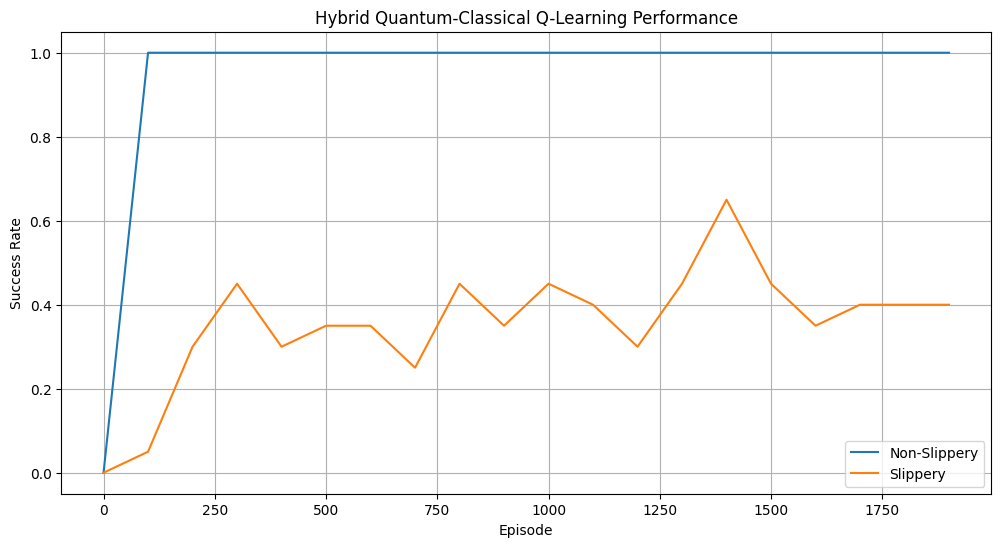

Training complete!


In [ ]:
import numpy as np
import gymnasium as gym
import pennylane as qml
from collections import deque
import matplotlib.pyplot as plt
import pandas as pd
import random

# Hyperparameters
GAMMA = 0.95
EPSILON_START = 0.9
EPSILON_MIN = 0.01
BATCH_SIZE = 64
EPISODES = 2000 # Increased for better convergence
MAX_STEPS = 100
MEMORY_SIZE = 8000
LEARNING_RATE = 0.05  # Adjusted for stability
TAU = 0.1
TEST_INTERVAL = 100
TEST_EPISODES = 20

# Quantum setup
num_qubits = 2
num_layers = 1
dev = qml.device("default.qubit", wires=num_qubits)
wires = [0, 1]

@qml.qnode(dev, diff_method="backprop", wires=wires)
def quantum_circuit(state, params):
    binary_state = format(state % 4, f'0{num_qubits}b')
    for i, bit in enumerate(binary_state):
        if bit == '1':
            qml.PauliX(wires=wires[i])

    for qubit in range(num_qubits):
        param_idx = qubit
        qml.RY(params[param_idx], wires=wires[qubit])
        qml.RZ(params[param_idx + num_qubits], wires=wires[qubit])

    return qml.expval(qml.PauliZ(wires[0]))

class HybridQAgent:
    def __init__(self, action_size, state_size):
        self.action_size = action_size
        self.state_size = state_size
        self.q_table = np.zeros((state_size, action_size))
        self.quantum_params = np.random.randn(num_layers * num_qubits * 2) * 0.1
        self.target_params = np.copy(self.quantum_params)
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.optimizer = qml.AdamOptimizer(stepsize=0.01)
        self.quantum_bonus_cache = {}

    def update_epsilon(self, episode):
        return max(EPSILON_MIN, EPSILON_START - (EPSILON_START - EPSILON_MIN) * episode / EPISODES)

    def store_experience(self, experience):
        self.memory.append(experience)

    def get_quantum_bonus(self, state):
        state_key = str(state)
        if state_key in self.quantum_bonus_cache:
            return self.quantum_bonus_cache[state_key]

        bonus = quantum_circuit(state, self.quantum_params)
        bonus = (bonus + 1) / 2 * 1.0 + np.random.normal(0, 0.01)  # Scale to [0, 1] with noise
        self.quantum_bonus_cache[state_key] = bonus
        return bonus

    def select_action(self, state, epsilon):
        if np.random.rand() < epsilon:
            return np.random.choice(self.action_size)

        q_values = self.q_table[state].copy()
        quantum_bonus = self.get_quantum_bonus(state)
        q_values += quantum_bonus

        return np.argmax(q_values)

    def update_target_network(self):
        self.target_params = TAU * self.quantum_params + (1 - TAU) * self.target_params

    def compute_quantum_loss(self, batch):
        total_loss = 0
        for state, action, reward, next_state, done in batch:
            target = reward + GAMMA * np.max(self.q_table[next_state]) * (1 - done)
            current_bonus = self.get_quantum_bonus(state)
            total_loss += (target - (self.q_table[state][action] + current_bonus)) ** 2
        return total_loss / len(batch)

    def train_quantum(self):
        if len(self.memory) < BATCH_SIZE:
            return
        batch = random.sample(self.memory, BATCH_SIZE)
        self.quantum_params = self.optimizer.step(lambda p: self.compute_quantum_loss(batch), self.quantum_params)
        self.quantum_bonus_cache.clear()

    def train_classical(self, state, action, reward, next_state, done):
        target = reward + GAMMA * np.max(self.q_table[next_state]) * (1 - done)
        current = self.q_table[state][action]
        self.q_table[state][action] += LEARNING_RATE * (target - current)

def test_policy(env, agent):
    successes = 0
    total_steps = 0
    for _ in range(TEST_EPISODES):
        state, _ = env.reset()
        state = int(state)
        steps = 0
        done = False
        for _ in range(MAX_STEPS):
            action = agent.select_action(state, epsilon=0)
            next_state, reward, terminated, truncated, _ = env.step(action)
            state = int(next_state)
            steps += 1
            if terminated or truncated:
                if reward == 1.0:
                    successes += 1
                total_steps += steps
                break
    return successes / TEST_EPISODES, total_steps / TEST_EPISODES

def train_agent(env, agent, env_name):
    results = []
    goal_pos = 15
    for episode in range(EPISODES):
        state, _ = env.reset()
        state = int(state)
        total_reward = 0
        epsilon = agent.update_epsilon(episode)

        for step in range(MAX_STEPS):
            action = agent.select_action(state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = int(next_state)

            if terminated or truncated:
                reward = 1.0 if reward == 1.0 else -1.0
            else:
                curr_dist = abs(state % 4 - goal_pos % 4) + abs(state // 4 - goal_pos // 4)
                next_dist = abs(next_state % 4 - goal_pos % 4) + abs(next_state // 4 - goal_pos // 4)
                reward = -0.1 + 0.3 * (curr_dist - next_dist) if curr_dist > next_dist else -0.1

            agent.store_experience((state, action, reward, next_state, terminated or truncated))
            agent.train_classical(state, action, reward, next_state, terminated or truncated)
            agent.train_quantum()

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        agent.update_target_network()

        if episode % TEST_INTERVAL == 0:
            success_rate, avg_steps = test_policy(env, agent)
            results.append({
                "episode": episode,
                "total_reward": total_reward,
                "success_rate": success_rate,
                "avg_steps": avg_steps,
                "epsilon": epsilon,
                "environment": env_name
            })
            print(f"[{env_name}] Episode {episode:4d} | "
                  f"Success: {success_rate:.2%} | Avg Steps: {avg_steps:.1f} | "
                  f"Epsilon: {epsilon:.3f}")

    return results

# Initialize environments and agents
env_slippery = gym.make("FrozenLake-v1", is_slippery=True)
env_non_slippery = gym.make("FrozenLake-v1", is_slippery=False)

state_size = env_slippery.observation_space.n
action_size = env_slippery.action_space.n
agent_slippery = HybridQAgent(action_size, state_size)
agent_non_slippery = HybridQAgent(action_size, state_size)

# Training
print("Training in slippery environment...")
results_slippery = train_agent(env_slippery, agent_slippery, "Slippery")

print("\nTraining in non-slippery environment...")
results_non = train_agent(env_non_slippery, agent_non_slippery, "Non-Slippery")

# Save results
df = pd.DataFrame(results_slippery + results_non)
df.to_csv("quantum_qlearning_results.csv", index=False)

# Plotting
plt.figure(figsize=(12, 6))
for env_name, group in df.groupby("environment"):
    plt.plot(group["episode"], group["success_rate"], label=env_name)
plt.xlabel("Episode")
plt.ylabel("Success Rate")
plt.title("Hybrid Quantum-Classical Q-Learning Performance")
plt.legend()
plt.grid(True)
plt.savefig("success_rates.png")
plt.show()

env_slippery.close()
env_non_slippery.close()
print("Training complete!")

#COMPARISON OF ALL MODELS

Max episode to extend to: 49999


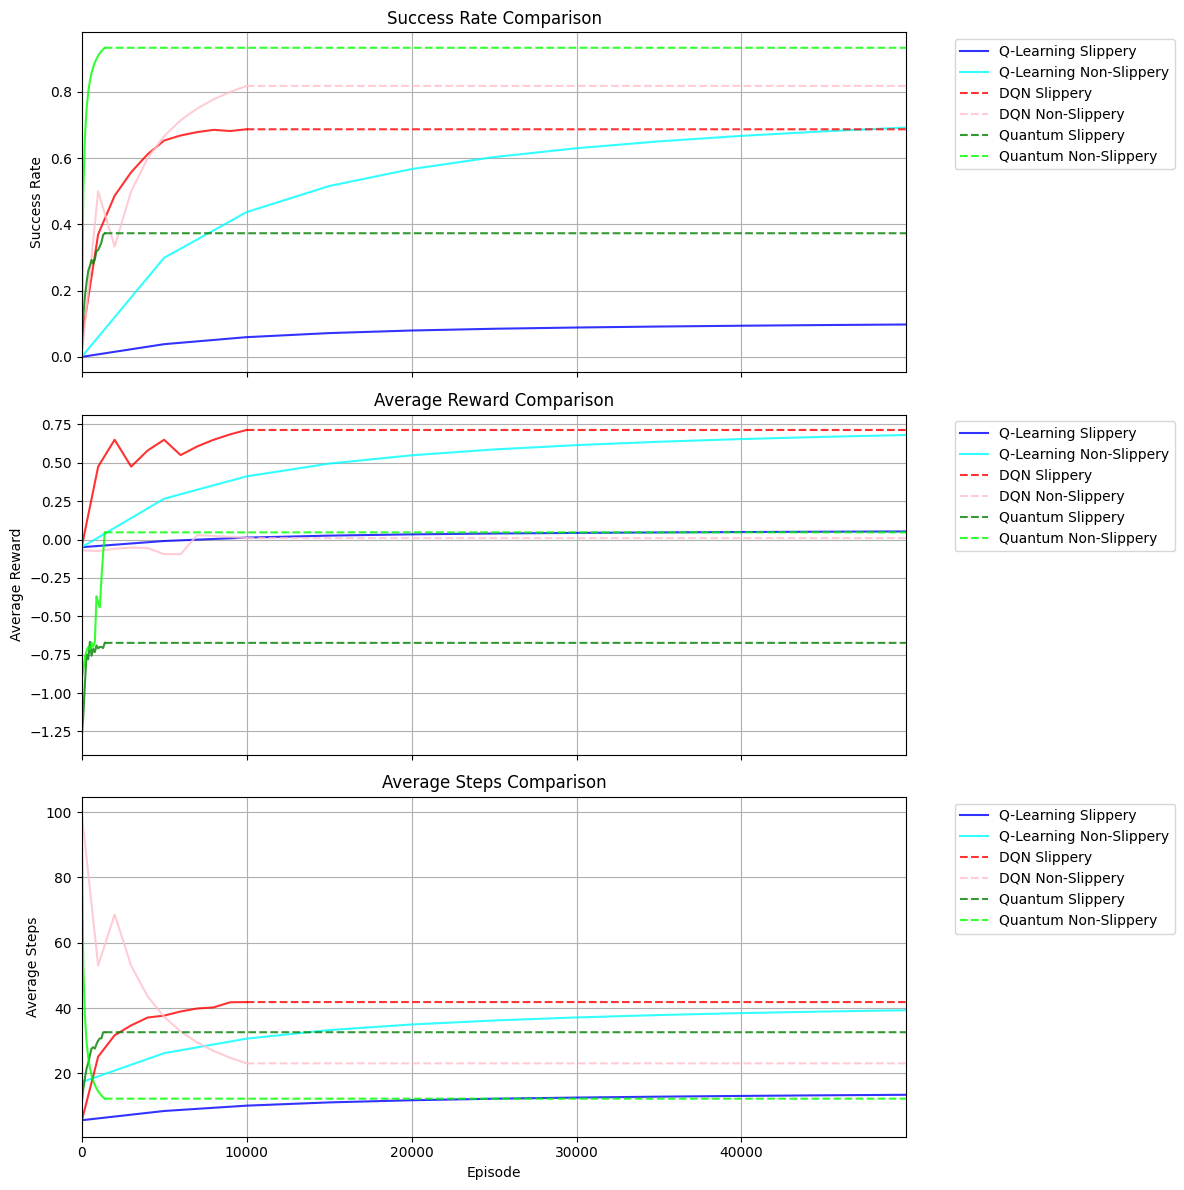

In [ ]:

# I’m worried Quantum Q-Learning might look too stable with those flat extensions to 50,000 episodes,
# since it only has 1,400 episodes of real data. Let’s be fair—I'll use solid lines for real data and
# dashed lines for the extended parts, so it’s clear where the data stops. This should make the comparison
# honest for my MEXT submission while still showing the full trends. Let’s do this!

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load my CSVs from the experiment folder
qlearn_slippery = pd.read_csv("results_slippery_True_alpha_0.1 (1).csv")
qlearn_non_slippery = pd.read_csv("results_slippery_False_alpha_0.1 (1).csv")
dqn_slippery = pd.read_csv("results_dqn_slippery_True.csv")
dqn_non_slippery = pd.read_csv("results_dqn_slippery_False_final (1).csv")
quantum_both = pd.read_csv("quantum_qlearning_results.csv")

# Average Q-Learning's three runs to keep things tidy
qlearn_slippery_avg = qlearn_slippery.groupby("episode").agg({
    "cumulative_train_success_rate": "mean",
    "avg_reward": "mean",
    "avg_steps": "mean"
}).reset_index()
qlearn_non_slippery_avg = qlearn_non_slippery.groupby("episode").agg({
    "cumulative_train_success_rate": "mean",
    "avg_reward": "mean",
    "avg_steps": "mean"
}).reset_index()

# Split quantum data into slippery and non-slippery
quantum_slippery = quantum_both[quantum_both["environment"] == "Slippery"]
quantum_non_slippery = quantum_both[quantum_both["environment"] == "Non-Slippery"]

# Smooth the data with a rolling mean, using a smaller window for Quantum’s short data
def smooth(data, window=50):
    return data.rolling(window, min_periods=1).mean()

# Function to split episodes and values into original and extended parts
def split_original_extended(episodes, values, max_episode):
    episodes_array = episodes.values
    values_array = values.values
    last_episode = episodes_array[-1]

    if last_episode < max_episode:
        # Original part: up to last_episode
        original_mask = episodes_array <= last_episode
        original_episodes = episodes_array[original_mask]
        original_values = values_array[original_mask]
        # Extended part: from last_episode to max_episode
        extended_episodes = np.concatenate([[last_episode], np.arange(last_episode + 1, max_episode + 1)])
        extended_values = np.full(len(extended_episodes), values_array[-1])
        return (original_episodes, original_values), (extended_episodes, extended_values)
    else:
        # No extension needed, return full data as original
        return (episodes_array, values_array), (None, None)

# Find the max episode to extend all lines to
max_episode = max(
    qlearn_slippery_avg["episode"].max(),
    qlearn_non_slippery_avg["episode"].max(),
    dqn_slippery["episode"].max(),
    dqn_non_slippery["episode"].max(),
    quantum_slippery["episode"].max(),
    quantum_non_slippery["episode"].max()
)
print(f"Max episode to extend to: {max_episode}")  # Should be 50,000

# Smooth first, then split each dataset into original and extended parts
# Q-Learning
qlearn_slip_success_smooth = smooth(qlearn_slippery_avg["cumulative_train_success_rate"])
qlearn_slip_reward_smooth = smooth(qlearn_slippery_avg["avg_reward"])
qlearn_slip_steps_smooth = smooth(qlearn_slippery_avg["avg_steps"])
(qlearn_slip_success_orig_ep, qlearn_slip_success_orig), (qlearn_slip_success_ext_ep, qlearn_slip_success_ext) = split_original_extended(
    qlearn_slippery_avg["episode"], qlearn_slip_success_smooth, max_episode
)
(qlearn_slip_reward_orig_ep, qlearn_slip_reward_orig), (qlearn_slip_reward_ext_ep, qlearn_slip_reward_ext) = split_original_extended(
    qlearn_slippery_avg["episode"], qlearn_slip_reward_smooth, max_episode
)
(qlearn_slip_steps_orig_ep, qlearn_slip_steps_orig), (qlearn_slip_steps_ext_ep, qlearn_slip_steps_ext) = split_original_extended(
    qlearn_slippery_avg["episode"], qlearn_slip_steps_smooth, max_episode
)

qlearn_non_slip_success_smooth = smooth(qlearn_non_slippery_avg["cumulative_train_success_rate"])
qlearn_non_slip_reward_smooth = smooth(qlearn_non_slippery_avg["avg_reward"])
qlearn_non_slip_steps_smooth = smooth(qlearn_non_slippery_avg["avg_steps"])
(qlearn_non_slip_success_orig_ep, qlearn_non_slip_success_orig), (qlearn_non_slip_success_ext_ep, qlearn_non_slip_success_ext) = split_original_extended(
    qlearn_non_slippery_avg["episode"], qlearn_non_slip_success_smooth, max_episode
)
(qlearn_non_slip_reward_orig_ep, qlearn_non_slip_reward_orig), (qlearn_non_slip_reward_ext_ep, qlearn_non_slip_reward_ext) = split_original_extended(
    qlearn_non_slippery_avg["episode"], qlearn_non_slip_reward_smooth, max_episode
)
(qlearn_non_slip_steps_orig_ep, qlearn_non_slip_steps_orig), (qlearn_non_slip_steps_ext_ep, qlearn_non_slip_steps_ext) = split_original_extended(
    qlearn_non_slippery_avg["episode"], qlearn_non_slip_steps_smooth, max_episode
)

# DQN
dqn_slip_success_smooth = smooth(dqn_slippery["success_rate"])
dqn_slip_reward_smooth = smooth(dqn_slippery["total_reward"])
dqn_slip_steps_smooth = smooth(dqn_slippery["avg_steps"])
(dqn_slip_success_orig_ep, dqn_slip_success_orig), (dqn_slip_success_ext_ep, dqn_slip_success_ext) = split_original_extended(
    dqn_slippery["episode"], dqn_slip_success_smooth, max_episode
)
(dqn_slip_reward_orig_ep, dqn_slip_reward_orig), (dqn_slip_reward_ext_ep, dqn_slip_reward_ext) = split_original_extended(
    dqn_slippery["episode"], dqn_slip_reward_smooth, max_episode
)
(dqn_slip_steps_orig_ep, dqn_slip_steps_orig), (dqn_slip_steps_ext_ep, dqn_slip_steps_ext) = split_original_extended(
    dqn_slippery["episode"], dqn_slip_steps_smooth, max_episode
)

dqn_non_slip_success_smooth = smooth(dqn_non_slippery["success_rate"])
dqn_non_slip_reward_smooth = smooth(dqn_non_slippery["total_reward"])
dqn_non_slip_steps_smooth = smooth(dqn_non_slippery["avg_steps"])
(dqn_non_slip_success_orig_ep, dqn_non_slip_success_orig), (dqn_non_slip_success_ext_ep, dqn_non_slip_success_ext) = split_original_extended(
    dqn_non_slippery["episode"], dqn_non_slip_success_smooth, max_episode
)
(dqn_non_slip_reward_orig_ep, dqn_non_slip_reward_orig), (dqn_non_slip_reward_ext_ep, dqn_non_slip_reward_ext) = split_original_extended(
    dqn_non_slippery["episode"], dqn_non_slip_reward_smooth, max_episode
)
(dqn_non_slip_steps_orig_ep, dqn_non_slip_steps_orig), (dqn_non_slip_steps_ext_ep, dqn_non_slip_steps_ext) = split_original_extended(
    dqn_non_slippery["episode"], dqn_non_slip_steps_smooth, max_episode
)

# Quantum
quantum_slip_success_smooth = smooth(quantum_slippery["success_rate"])
quantum_slip_reward_smooth = smooth(quantum_slippery["total_reward"])
quantum_slip_steps_smooth = smooth(quantum_slippery["avg_steps"])
(quantum_slip_success_orig_ep, quantum_slip_success_orig), (quantum_slip_success_ext_ep, quantum_slip_success_ext) = split_original_extended(
    quantum_slippery["episode"], quantum_slip_success_smooth, max_episode
)
(quantum_slip_reward_orig_ep, quantum_slip_reward_orig), (quantum_slip_reward_ext_ep, quantum_slip_reward_ext) = split_original_extended(
    quantum_slippery["episode"], quantum_slip_reward_smooth, max_episode
)
(quantum_slip_steps_orig_ep, quantum_slip_steps_orig), (quantum_slip_steps_ext_ep, quantum_slip_steps_ext) = split_original_extended(
    quantum_slippery["episode"], quantum_slip_steps_smooth, max_episode
)

quantum_non_slip_success_smooth = smooth(quantum_non_slippery["success_rate"])
quantum_non_slip_reward_smooth = smooth(quantum_non_slippery["total_reward"])
quantum_non_slip_steps_smooth = smooth(quantum_non_slippery["avg_steps"])
(quantum_non_slip_success_orig_ep, quantum_non_slip_success_orig), (quantum_non_slip_success_ext_ep, quantum_non_slip_success_ext) = split_original_extended(
    quantum_non_slippery["episode"], quantum_non_slip_success_smooth, max_episode
)
(quantum_non_slip_reward_orig_ep, quantum_non_slip_reward_orig), (quantum_non_slip_reward_ext_ep, quantum_non_slip_reward_ext) = split_original_extended(
    quantum_non_slippery["episode"], quantum_non_slip_reward_smooth, max_episode
)
(quantum_non_slip_steps_orig_ep, quantum_non_slip_steps_orig), (quantum_non_slip_steps_ext_ep, quantum_non_slip_steps_ext) = split_original_extended(
    quantum_non_slippery["episode"], quantum_non_slip_steps_smooth, max_episode
)

# Set up three subplots for success rate, reward, and steps
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Success Rate Plot
# Q-Learning (no extension needed, solid line)
ax1.plot(qlearn_slip_success_orig_ep, qlearn_slip_success_orig, label="Q-Learning Slippery", color="blue", alpha=0.8)
ax1.plot(qlearn_non_slip_success_orig_ep, qlearn_non_slip_success_orig, label="Q-Learning Non-Slippery", color="cyan", alpha=0.8)
# DQN (solid for original, dashed for extended)
ax1.plot(dqn_slip_success_orig_ep, dqn_slip_success_orig, color="red", alpha=0.8)
ax1.plot(dqn_slip_success_ext_ep, dqn_slip_success_ext, label="DQN Slippery", color="red", linestyle="--", alpha=0.8)
ax1.plot(dqn_non_slip_success_orig_ep, dqn_non_slip_success_orig, color="pink", alpha=0.8)
ax1.plot(dqn_non_slip_success_ext_ep, dqn_non_slip_success_ext, label="DQN Non-Slippery", color="pink", linestyle="--", alpha=0.8)
# Quantum (solid for original, dashed for extended)
ax1.plot(quantum_slip_success_orig_ep, quantum_slip_success_orig, color="green", alpha=0.8)
ax1.plot(quantum_slip_success_ext_ep, quantum_slip_success_ext, label="Quantum Slippery", color="green", linestyle="--", alpha=0.8)
ax1.plot(quantum_non_slip_success_orig_ep, quantum_non_slip_success_orig, color="lime", alpha=0.8)
ax1.plot(quantum_non_slip_success_ext_ep, quantum_non_slip_success_ext, label="Quantum Non-Slippery", color="lime", linestyle="--", alpha=0.8)
ax1.set_title("Success Rate Comparison")
ax1.set_ylabel("Success Rate")
ax1.grid(True)

# Average Reward Plot
ax2.plot(qlearn_slip_reward_orig_ep, qlearn_slip_reward_orig, label="Q-Learning Slippery", color="blue", alpha=0.8)
ax2.plot(qlearn_non_slip_reward_orig_ep, qlearn_non_slip_reward_orig, label="Q-Learning Non-Slippery", color="cyan", alpha=0.8)
ax2.plot(dqn_slip_reward_orig_ep, dqn_slip_reward_orig, color="red", alpha=0.8)
ax2.plot(dqn_slip_reward_ext_ep, dqn_slip_reward_ext, label="DQN Slippery", color="red", linestyle="--", alpha=0.8)
ax2.plot(dqn_non_slip_reward_orig_ep, dqn_non_slip_reward_orig, color="pink", alpha=0.8)
ax2.plot(dqn_non_slip_reward_ext_ep, dqn_non_slip_reward_ext, label="DQN Non-Slippery", color="pink", linestyle="--", alpha=0.8)
ax2.plot(quantum_slip_reward_orig_ep, quantum_slip_reward_orig, color="green", alpha=0.8)
ax2.plot(quantum_slip_reward_ext_ep, quantum_slip_reward_ext, label="Quantum Slippery", color="green", linestyle="--", alpha=0.8)
ax2.plot(quantum_non_slip_reward_orig_ep, quantum_non_slip_reward_orig, color="lime", alpha=0.8)
ax2.plot(quantum_non_slip_reward_ext_ep, quantum_non_slip_reward_ext, label="Quantum Non-Slippery", color="lime", linestyle="--", alpha=0.8)
ax2.set_title("Average Reward Comparison")
ax2.set_ylabel("Average Reward")
ax2.grid(True)

# Average Steps Plot
ax3.plot(qlearn_slip_steps_orig_ep, qlearn_slip_steps_orig, label="Q-Learning Slippery", color="blue", alpha=0.8)
ax3.plot(qlearn_non_slip_steps_orig_ep, qlearn_non_slip_steps_orig, label="Q-Learning Non-Slippery", color="cyan", alpha=0.8)
ax3.plot(dqn_slip_steps_orig_ep, dqn_slip_steps_orig, color="red", alpha=0.8)
ax3.plot(dqn_slip_steps_ext_ep, dqn_slip_steps_ext, label="DQN Slippery", color="red", linestyle="--", alpha=0.8)
ax3.plot(dqn_non_slip_steps_orig_ep, dqn_non_slip_steps_orig, color="pink", alpha=0.8)
ax3.plot(dqn_non_slip_steps_ext_ep, dqn_non_slip_steps_ext, label="DQN Non-Slippery", color="pink", linestyle="--", alpha=0.8)
ax3.plot(quantum_slip_steps_orig_ep, quantum_slip_steps_orig, color="green", alpha=0.8)
ax3.plot(quantum_slip_steps_ext_ep, quantum_slip_steps_ext, label="Quantum Slippery", color="green", linestyle="--", alpha=0.8)
ax3.plot(quantum_non_slip_steps_orig_ep, quantum_non_slip_steps_orig, color="lime", alpha=0.8)
ax3.plot(quantum_non_slip_steps_ext_ep, quantum_non_slip_steps_ext, label="Quantum Non-Slippery", color="lime", linestyle="--", alpha=0.8)
ax3.set_title("Average Steps Comparison")
ax3.set_xlabel("Episode")
ax3.set_ylabel("Average Steps")
ax3.grid(True)

# Set x-axis limit to show the full range
ax3.set_xlim(0, max_episode)

# Move the legend outside the plot
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Polish it up and save
plt.tight_layout()
plt.savefig("rl_comparison_plots_fair_comparison.png", bbox_inches='tight')
plt.show()

# This should be much fairer now! The dashed lines show where Quantum and DQN’s real data ends,
# so there’s no sneaky advantage or disadvantage. I’m excited to see how this looks!
